# 03 — Exploratory Data Analysis

Look at the data before testing anything. Build expectations, surface oddities,
and check whether confounders (recruitment site, stool type) structure the data
as strongly as disease status does.

Inputs:  genus_counts.csv, genus_clr.csv, metadata.csv, taxonomy.csv
Outputs: figures saved to results/figures/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from config import PARAMS, PATHS

PROCESSED = "../data/processed/"
FIGURES   = "../results/figures/"

# Load everything notebook 02 produced
counts = pd.read_csv(PROCESSED + "genus_counts.csv", index_col="sample_id")
clr_df = pd.read_csv(PROCESSED + "genus_clr.csv",    index_col="sample_id")
meta   = pd.read_csv(PROCESSED + "metadata.csv",     index_col="sample_id")
tax    = pd.read_csv(PROCESSED + "taxonomy.csv",     index_col="asv_id")

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print(f"Counts: {counts.shape}")
print(f"CLR:    {clr_df.shape}")
print(f"Meta:   {meta.shape}")
print(f"\nDisease split:\n{meta['disease_status'].value_counts()}")
print(f"\nLocation split:\n{meta['location'].value_counts()}")

Counts: (2238, 128)
CLR:    (2238, 128)
Meta:   (2238, 6)

Disease split:
disease_status
HC    1204
RA    1034
Name: count, dtype: int64

Location split:
location
Beijing      1928
Shanxi        129
Henan         105
Hubei          47
Guangdong      29
Name: count, dtype: int64


In [2]:
print(pd.crosstab(meta["location"], meta["disease_status"]))
print()
print(pd.crosstab(meta["location"], meta["disease_status"], normalize="index").round(3))

disease_status    HC   RA
location                 
Beijing         1109  819
Guangdong          9   20
Henan             40   65
Hubei              0   47
Shanxi            46   83

disease_status     HC     RA
location                    
Beijing         0.575  0.425
Guangdong       0.310  0.690
Henan           0.381  0.619
Hubei           0.000  1.000
Shanxi          0.357  0.643


In [3]:
# ── Stratify: Beijing as primary cohort ──────────────────────────────────
beijing_samples = meta.index[meta["location"] == "Beijing"]

meta_bj   = meta.loc[beijing_samples]
counts_bj = counts.loc[beijing_samples]
clr_bj    = clr_df.loc[beijing_samples]

# Non-Beijing held back as a replication set
other_samples = meta.index[meta["location"] != "Beijing"]
meta_other   = meta.loc[other_samples]
counts_other = counts.loc[other_samples]
clr_other    = clr_df.loc[other_samples]

print("PRIMARY COHORT (Beijing)")
print(f"  Samples: {len(beijing_samples)}")
print(meta_bj["disease_status"].value_counts())

print("\nREPLICATION SET (non-Beijing)")
print(f"  Samples: {len(other_samples)}")
print(meta_other["disease_status"].value_counts())
print(meta_other["location"].value_counts())

PRIMARY COHORT (Beijing)
  Samples: 1928
disease_status
HC    1109
RA     819
Name: count, dtype: int64

REPLICATION SET (non-Beijing)
  Samples: 310
disease_status
RA    215
HC     95
Name: count, dtype: int64
location
Shanxi       129
Henan        105
Hubei         47
Guangdong     29
Name: count, dtype: int64


In [4]:
# 1. Genus → Phylum lookup (one row per genus)
genus_to_phylum = (
    tax[["Genus", "Phylum"]]
    .drop_duplicates()
    .set_index("Genus")["Phylum"]
)

# Keep only genera present in our filtered table
genus_to_phylum = genus_to_phylum[genus_to_phylum.index.isin(counts_bj.columns)]
genus_to_phylum = genus_to_phylum[~genus_to_phylum.index.duplicated()]

# 2. Roll counts up from genus to phylum
phylum_counts = counts_bj.T.groupby(genus_to_phylum).sum().T

# 3. Convert to relative abundance (proportions per sample)
phylum_rel = phylum_counts.div(phylum_counts.sum(axis=1), axis=0)

# 4. Mean proportion within each disease group
phylum_rel = phylum_rel.join(meta_bj["disease_status"])
phylum_mean = phylum_rel.groupby("disease_status").mean()

print("Mean phylum composition (Beijing cohort):")
print((phylum_mean * 100).round(2).T.sort_values("HC", ascending=False))

Mean phylum composition (Beijing cohort):
disease_status      HC     RA
Firmicutes       65.11  66.56
Bacteroidetes    23.77  21.86
Proteobacteria    7.51   7.03
Actinobacteria    2.96   4.05
Fusobacteria      0.29   0.26
Tenericutes       0.27   0.18
Patescibacteria   0.06   0.05
Verrucomicrobia   0.02   0.01


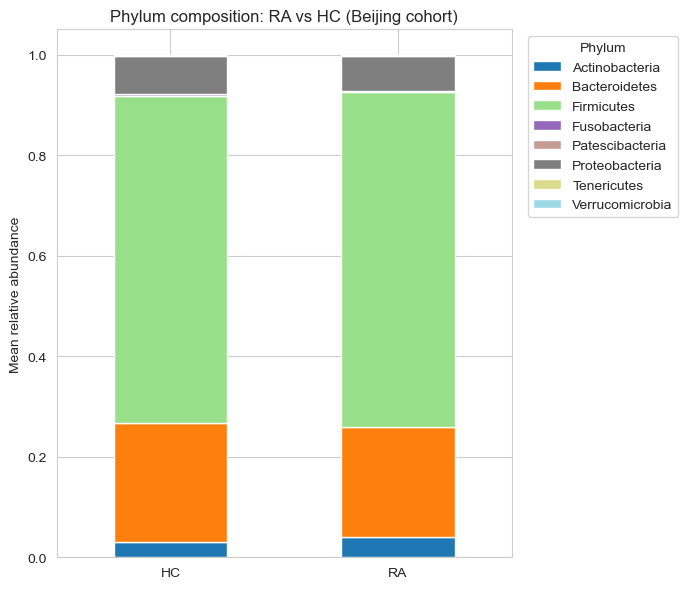

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

phylum_mean.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")

ax.set_ylabel("Mean relative abundance")
ax.set_xlabel("")
ax.set_title("Phylum composition: RA vs HC (Beijing cohort)")
ax.legend(title="Phylum", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES + "phylum_composition.png", dpi=200, bbox_inches="tight")
plt.show()

/opt/anaconda3/envs/ra-microbiome/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


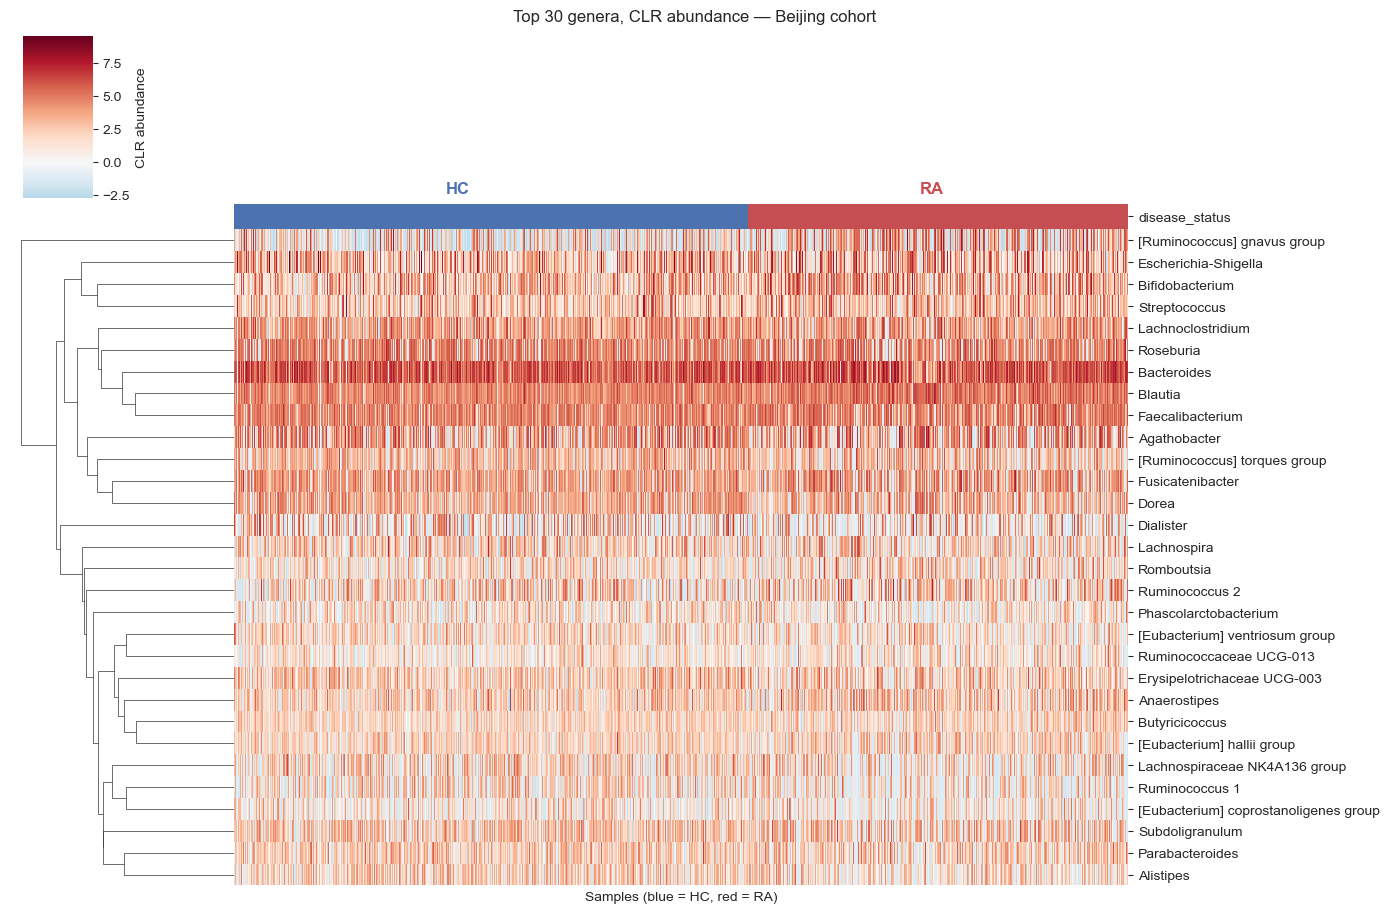

In [6]:
# Top 30 genera by mean CLR abundance
top_genera = clr_bj.mean().sort_values(ascending=False).head(30).index

# Order samples by disease status so groups form visible blocks
sample_order = meta_bj.sort_values("disease_status").index
heat_data = clr_bj.loc[sample_order, top_genera].T

# Colour bar along the top marking which group each sample belongs to
group_colours = meta_bj.loc[sample_order, "disease_status"].map(
    {"HC": "#4C72B0", "RA": "#C44E52"}
)

g = sns.clustermap(
    heat_data,
    col_cluster=False,          # keep samples in disease-status order
    row_cluster=True,           # cluster genera by similarity
    col_colors=group_colours,
    cmap="RdBu_r",
    center=0,
    figsize=(14, 9),
    xticklabels=False,          # 1928 sample labels would be unreadable
    yticklabels=True,
    cbar_kws={"label": "CLR abundance"}
)

g.ax_heatmap.set_xlabel("Samples (blue = HC, red = RA)")
g.ax_heatmap.set_ylabel("")
g.fig.suptitle("Top 30 genera, CLR abundance — Beijing cohort", y=1.01)

g.ax_col_colors.text(0.25, 1.4, "HC", transform=g.ax_col_colors.transAxes,
                     ha="center", fontsize=12, fontweight="bold", color="#4C72B0")
g.ax_col_colors.text(0.78, 1.4, "RA", transform=g.ax_col_colors.transAxes,
                     ha="center", fontsize=12, fontweight="bold", color="#C44E52")

plt.savefig(FIGURES + "genus_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
# Mean CLR per genus in each group
means = clr_bj.join(meta_bj["disease_status"]).groupby("disease_status").mean().T
means["difference"] = means["RA"] - means["HC"]

print("Top 15 enriched in RA:")
print(means.sort_values("difference", ascending=False).head(15).round(3))

print("\nTop 15 depleted in RA:")
print(means.sort_values("difference").head(15).round(3))

Top 15 enriched in RA:
disease_status                   HC     RA  difference
[Ruminococcus] gnavus group   0.830  2.138       1.308
Erysipelatoclostridium       -0.990 -0.130       0.860
Veillonella                  -0.870 -0.035       0.835
Tyzzerella 4                 -1.068 -0.254       0.814
Bifidobacterium               2.724  3.343       0.619
Intestinibacter              -0.162  0.401       0.563
Clostridium sensu stricto 1   0.520  1.066       0.546
Lactobacillus                -0.868 -0.342       0.526
Terrisporobacter             -1.359 -0.871       0.488
Blautia                       4.450  4.878       0.428
Flavonifractor               -0.036  0.385       0.421
Streptococcus                 2.470  2.886       0.416
Turicibacter                 -0.746 -0.339       0.407
[Clostridium] innocuum group -1.229 -0.826       0.403
Granulicatella               -1.369 -0.979       0.390

Top 15 depleted in RA:
disease_status                      HC     RA  difference
Klebsiella     

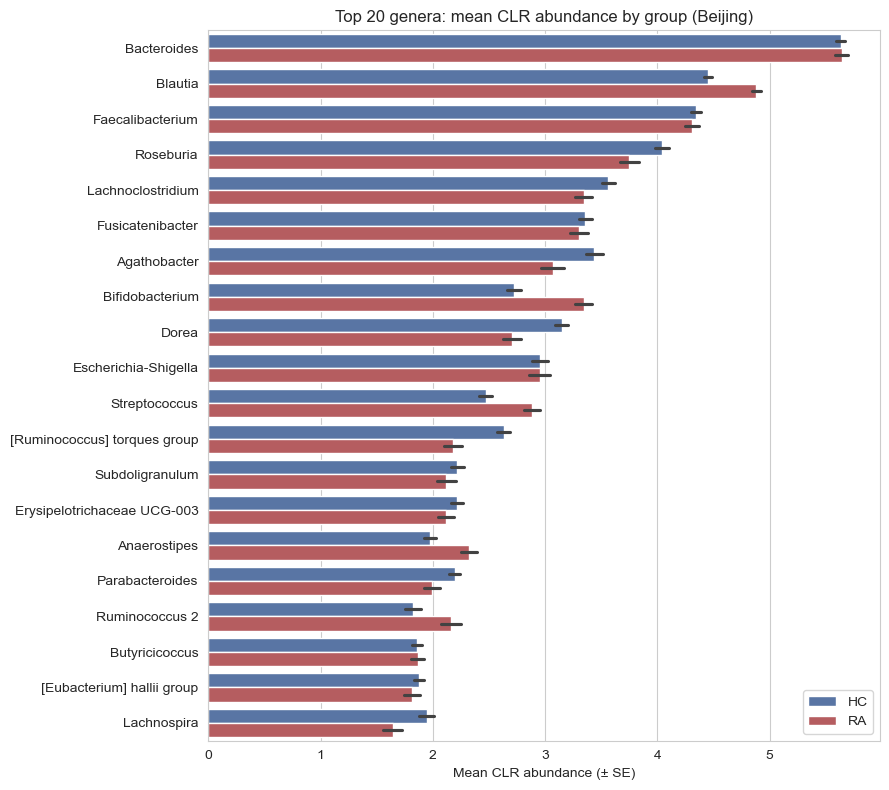

In [8]:
top20 = clr_bj.mean().sort_values(ascending=False).head(20).index

plot_df = clr_bj[top20].join(meta_bj["disease_status"])
plot_long = plot_df.melt(id_vars="disease_status",
                         var_name="Genus", value_name="CLR")

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=plot_long, y="Genus", x="CLR", hue="disease_status",
            palette={"HC": "#4C72B0", "RA": "#C44E52"},
            errorbar="se", ax=ax)
ax.set_title("Top 20 genera: mean CLR abundance by group (Beijing)")
ax.set_xlabel("Mean CLR abundance (± SE)")
ax.set_ylabel("")
ax.legend(title="")
plt.tight_layout()
plt.savefig(FIGURES + "genus_abundance.png", dpi=200, bbox_inches="tight")
plt.show()

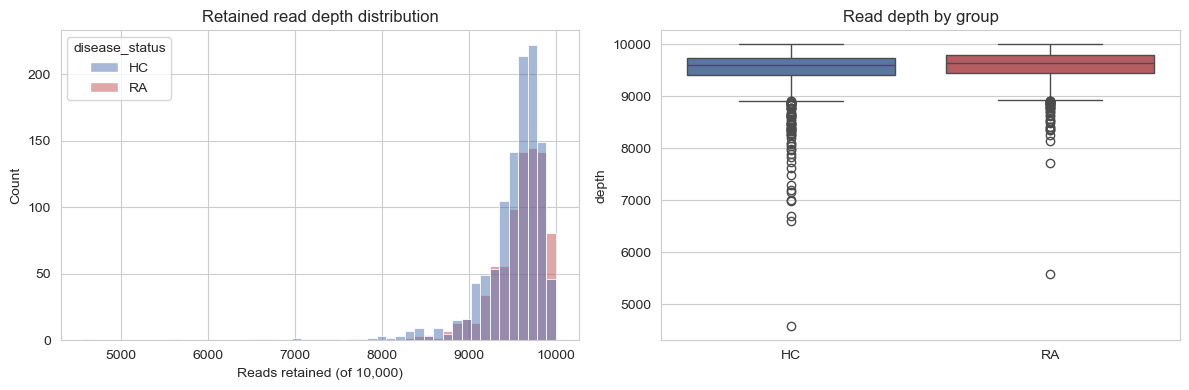

                 count    mean    std     min     25%     50%     75%      max
disease_status                                                                
HC              1109.0  9502.0  423.0  4572.0  9407.0  9609.0  9740.0  10000.0
RA               819.0  9574.0  336.0  5580.0  9447.0  9645.0  9796.0  10000.0

10 lowest-depth samples:
           depth disease_status
sample_id                      
HC0745      4572             HC
RA0865      5580             RA
HC0952      6596             HC
HC1512      6693             HC
HC0884      6982             HC
HC1030      7010             HC
HC1106      7161             HC
HC1384      7204             HC
HC1513      7296             HC
HC0607      7485             HC


In [9]:
# Read depth after all preprocessing
depth = counts_bj.sum(axis=1)
depth_df = pd.DataFrame({"depth": depth}).join(meta_bj["disease_status"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=depth_df, x="depth", hue="disease_status",
             palette={"HC": "#4C72B0", "RA": "#C44E52"},
             bins=50, ax=axes[0])
axes[0].set_title("Retained read depth distribution")
axes[0].set_xlabel("Reads retained (of 10,000)")

sns.boxplot(data=depth_df, x="disease_status", y="depth",
            hue="disease_status", legend=False,
            palette={"HC": "#4C72B0", "RA": "#C44E52"}, ax=axes[1])
axes[1].set_title("Read depth by group")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(FIGURES + "read_depth.png", dpi=200, bbox_inches="tight")
plt.show()
print(depth_df.groupby("disease_status")["depth"].describe().round(0))

# Find the low-depth outliers
print("\n10 lowest-depth samples:")
print(depth_df.sort_values("depth").head(10))


In [10]:
from scipy.stats import mannwhitneyu

hc_depth = depth_df.loc[depth_df.disease_status == "HC", "depth"]
ra_depth = depth_df.loc[depth_df.disease_status == "RA", "depth"]

stat, p = mannwhitneyu(hc_depth, ra_depth)
print(f"Mann-Whitney U: p = {p:.4g}")
print(f"HC median: {hc_depth.median():.0f}   RA median: {ra_depth.median():.0f}")

Mann-Whitney U: p = 1.52e-05
HC median: 9609   RA median: 9645
